In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch

# Depth Anything 3
from depth_anything_3.api import DepthAnything3
from depth_anything_3.utils.visualize import visualize_depth

# SAM 3
import sam3
from sam3.model_builder import build_sam3_image_model
from sam3.model.box_ops import box_xywh_to_cxcywh
from sam3.model.sam3_image_processor import Sam3Processor
from sam3.visualization_utils import draw_box_on_image, normalize_bbox, plot_results

  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)



In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True
torch.autocast("cuda", dtype=torch.bfloat16).__enter__()
print(f"Using device: {device}")

Using device: cuda


In [3]:
depth_model = DepthAnything3.from_pretrained("depth-anything/DA3NESTED-GIANT-LARGE")
depth_model = depth_model.to(device)
depth_model.eval()
print("Depth Anything 3 loaded")

[INFO ] using SwiGLU layer as FFN
[INFO ] using MLP layer as FFN
Depth Anything 3 loaded


In [4]:
bpe_path = f"sam3/sam3/assets/bpe_simple_vocab_16e6.txt.gz"
sam_model = build_sam3_image_model(bpe_path=bpe_path)
print("SAM 3 loaded")

SAM 3 loaded


In [20]:
image_path = "sam3/assets/images/test_image.jpg"   # <-- change to your image
text_prompt = "children"                             # <-- change to your target object

In [21]:
prediction = depth_model.inference(
    image=[image_path],
    process_res=504,
    process_res_method="upper_bound_resize",
    export_dir=None,
    export_format="glb"
)

depth_map = prediction.depth[0]          # [H, W] float32
processed_image = prediction.processed_images[0]  # [H, W, 3] uint8

print(f"Depth map shape: {depth_map.shape}")
print(f"Depth range: {depth_map.min():.3f} – {depth_map.max():.3f}")


[INFO ] Processed Images Done taking 0.21584391593933105 seconds. Shape:  torch.Size([1, 3, 280, 504])
[INFO ] Model Forward Pass Done. Time: 0.5075232982635498 seconds
[INFO ] Conversion to Prediction Done. Time: 0.002496480941772461 seconds
Depth map shape: (280, 504)
Depth range: 4.239 – 28.906


In [22]:
image_pil = Image.open(image_path)
width, height = image_pil.size

processor = Sam3Processor(sam_model, confidence_threshold=0.5)
inference_state = processor.set_image(image_pil)

processor.reset_all_prompts(inference_state)
inference_state = processor.set_text_prompt(state=inference_state, prompt=text_prompt)

masks  = inference_state["masks"]
scores = inference_state["scores"]

# Cast to float32 first to avoid bfloat16 numpy conversion error
scores_np = scores.cpu().float().numpy() if isinstance(scores, torch.Tensor) else np.array(scores, dtype=np.float32)
masks_np  = masks.cpu().float().numpy()  if isinstance(masks,  torch.Tensor) else np.array(masks)
masks_np  = masks_np.astype(bool)

# Pick best mask
best_idx  = int(np.argmax(scores_np)) if len(scores_np) > 0 else 0
best_mask = masks_np[best_idx]
print(f"Found {len(masks_np)} mask(s) — using highest-scoring (score={scores_np[best_idx]:.3f})")

Found 6 mask(s) — using highest-scoring (score=0.957)


In [23]:
from PIL import Image as PILImage

depth_pil = PILImage.fromarray(depth_map).resize((width, height), PILImage.BILINEAR)
depth_resized = np.array(depth_pil)

# Squeeze out any extra dimensions SAM 3 adds (e.g. [1, 1, H, W] -> [H, W])
best_mask_squeezed = best_mask.squeeze()
print(f"Mask shape after squeeze: {best_mask_squeezed.shape}")

mask_resized = best_mask_squeezed
if best_mask_squeezed.shape != depth_resized.shape:
    mask_pil = PILImage.fromarray(best_mask_squeezed.astype(np.uint8) * 255).resize(
        (width, height), PILImage.NEAREST
    )
    mask_resized = np.array(mask_pil) > 0

mean_depth   = depth_resized[mask_resized].mean()
median_depth = np.median(depth_resized[mask_resized])
print(f"'{text_prompt}' — mean depth: {mean_depth:.3f}, median depth: {median_depth:.3f}")

Mask shape after squeeze: (720, 1280)
'children' — mean depth: 7.790, median depth: 7.614


=== SAM 3 segmentation result ===
found 6 object(s)


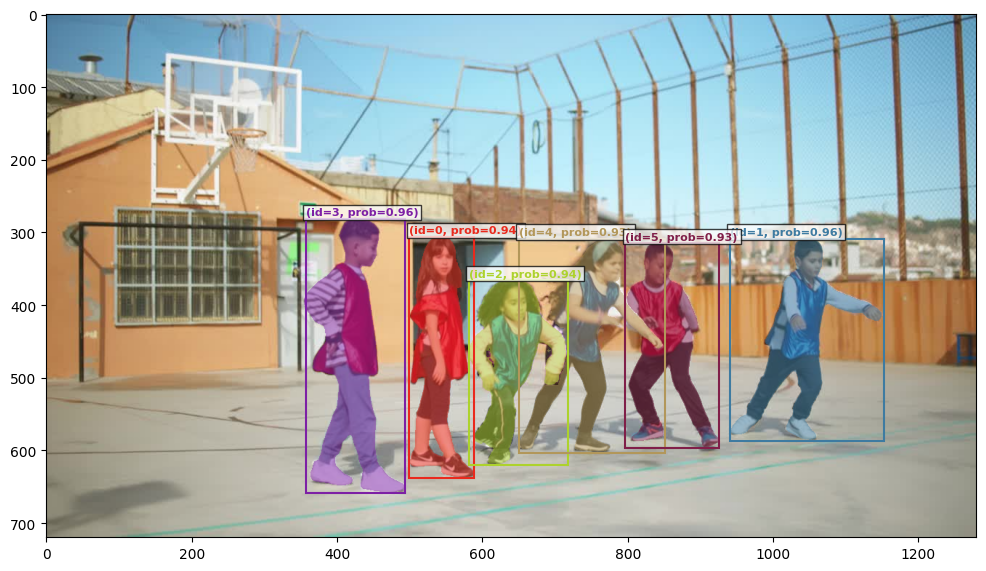

In [26]:
print("=== SAM 3 segmentation result ===")
plot_results(image_pil, inference_state)

Applied depth overlay to 6 instance(s) of 'children'


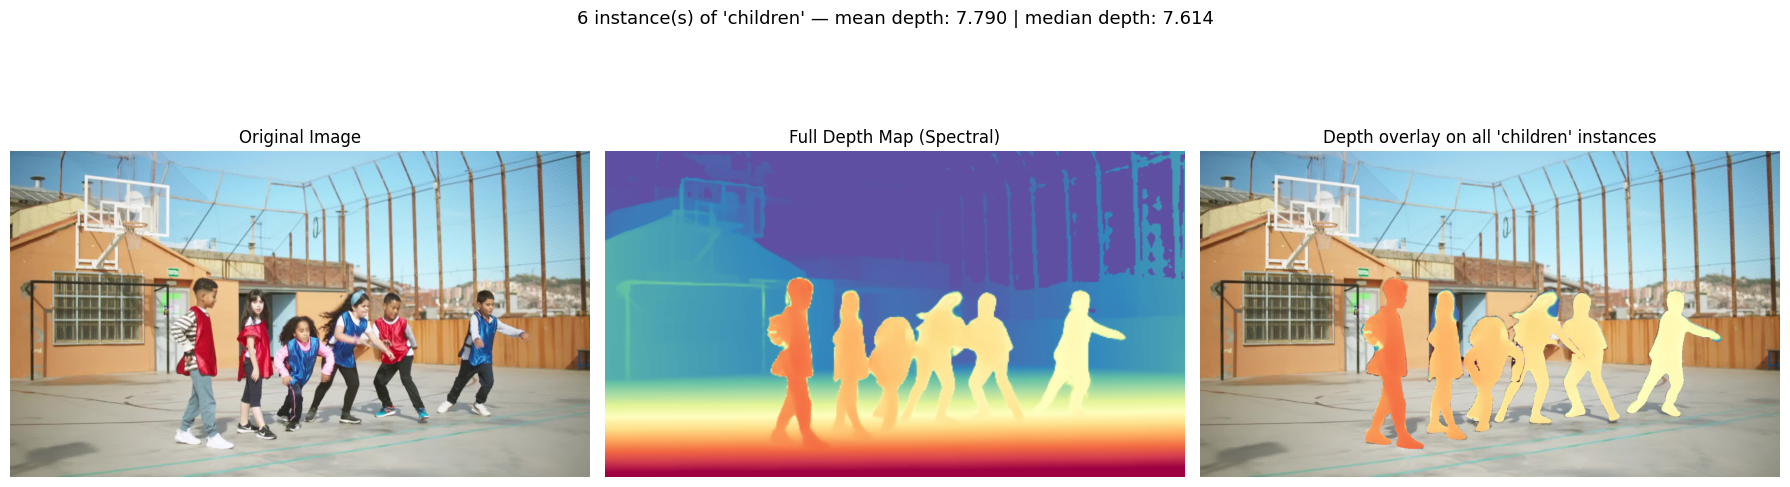

Saved to combined_output.png


In [25]:
# Resize depth visualization to original image size
depth_vis = visualize_depth(depth_map, cmap="Spectral")  # [H, W, 3] uint8
depth_vis_pil = PILImage.fromarray(depth_vis).resize((width, height), PILImage.BILINEAR)
depth_vis_resized = np.array(depth_vis_pil)

image_np = np.array(image_pil)

# Build composite: apply depth colors for every mask SAM3 found
composite = image_np.copy()
for i, mask in enumerate(masks_np):
    # Squeeze and resize each mask to match original image
    mask_squeezed = mask.squeeze()
    if mask_squeezed.shape != (height, width):
        mask_pil_i = PILImage.fromarray(mask_squeezed.astype(np.uint8) * 255).resize(
            (width, height), PILImage.NEAREST
        )
        mask_squeezed = np.array(mask_pil_i) > 0
    composite[mask_squeezed] = depth_vis_resized[mask_squeezed]

print(f"Applied depth overlay to {len(masks_np)} instance(s) of '{text_prompt}'")

# Plot
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(image_np)
axes[0].set_title("Original Image")
axes[0].axis("off")

axes[1].imshow(depth_vis_resized)
axes[1].set_title("Full Depth Map (Spectral)")
axes[1].axis("off")

axes[2].imshow(composite)
axes[2].set_title(f"Depth overlay on all '{text_prompt}' instances")
axes[2].axis("off")

plt.suptitle(
    f"{len(masks_np)} instance(s) of '{text_prompt}' — mean depth: {mean_depth:.3f} | median depth: {median_depth:.3f}",
    fontsize=13
)
plt.tight_layout()
plt.savefig("combined_output.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to combined_output.png")